# Raw-Reservoir-State Prediction with XGBoost and Bayesian Optimization

This notebook predicts thermal conductivity (`k`) and effusivity (`eff`) from the
initial post-contact thermal response at one fixed temperature.

It uses two feature families:

1. **Thermal-response features** — interpretable slopes, changes, areas and cross-sensor quantities.
2. **Raw ESN states** — the reservoir trajectory, resampled to a fixed grid and flattened without statistical summaries.

The regression readout is **XGBoost**, which can model nonlinear interactions without
PCA. ESN hyperparameters are selected with Gaussian-process Bayesian optimization.
The nested LOMO implementation keeps each outer test material completely outside
feature scaling, model fitting, and hyperparameter selection.


# 1. Imports and experiment configuration


In [37]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from scipy import linalg
from scipy.signal import savgol_filter
from scipy.stats import norm
from sklearn.compose import TransformedTargetRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import GroupKFold, LeaveOneGroupOut
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from xgboost import XGBRegressor


In [38]:
FILE_TITLE = "60C"
RANDOM_STATE = 42

# Analyze only the initial post-contact transient.
# All thermal-response features below use this complete interval.
ANALYSIS_WINDOW = (0.0, 5.0)

# Manual ESN settings.
#ESN_RES_SIZE = 20
#ESN_LEAK_RATE = 0.1
#ESN_INPUT_MAGNITUDE = 1.5
#ESN_SPECTRAL_RADIUS = 0.7
#ESN_WASHOUT = 5

#Bayesian Optimal HPs
ESN_RES_SIZE = 73
ESN_LEAK_RATE = 0.755731
ESN_INPUT_MAGNITUDE = 0.991535
ESN_SPECTRAL_RADIUS = 1.103213
ESN_WASHOUT = 1

# Number of positions retained from each post-washout state trajectory.
RAW_STATE_TIME_POINTS = 11

# Fixed XGBoost settings. Bayesian optimization below selects ESN dynamics;
# keeping the readout fixed makes the ESN comparison identifiable and affordable.
XGB_PARAMS = {
    "n_estimators": 300,
    "max_depth": 3,
    "learning_rate": 0.03,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "min_child_weight": 2.0,
    "reg_alpha": 0.0,
    "reg_lambda": 1.0,
}

# Bayesian ESN search controls.
BAYES_N_TRIALS = 24
BAYES_N_INITIAL = 8
BAYES_ACQUISITION_CANDIDATES = 1024
BAYES_STABILITY_WEIGHT = 0.25

cwd = Path.cwd().resolve()
data_candidates = [
    cwd / "data" / "02_preprocessed" / FILE_TITLE,
    cwd.parent / "data" / "02_preprocessed" / FILE_TITLE,
    cwd.parent.parent / "Warmth Sensor Notebook" / "data" / "02_preprocessed" / FILE_TITLE,
]
DATA_PATH = next((path for path in data_candidates if path.is_dir()), None)
if DATA_PATH is None:
    attempted = "\n".join(str(path) for path in data_candidates)
    raise FileNotFoundError(f"Data directory not found. Tried:\n{attempted}")


# 2. Standard material properties and trial loading

The processed CSV values in `k`, `Mass`, `Volume`, `rho`, and `cp` are deliberately
ignored. After loading the sensor data, the notebook overwrites those fields using
the authoritative table below.

`Mass=1 kg` and `Volume=1 m³` are placeholders and can be updated later.


In [39]:
STANDARD_PROPERTIES = {
    "ps_foam":   {"k": 0.034, "Mass": 1.0, "Volume": 1.0, "rho": 25.0,   "cp": 1400.0},
    "pu_foam":   {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 30.0,   "cp": 1400.0},
    "cork":      {"k": 0.043, "Mass": 1.0, "Volume": 1.0, "rho": 240.0,  "cp": 1800.0},
    "wood":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 700.0,  "cp": 1700.0},
    "pdms":      {"k": 0.150, "Mass": 1.0, "Volume": 1.0, "rho": 970.0,  "cp": 1460.0},
    "gypsum":    {"k": 0.170, "Mass": 1.0, "Volume": 1.0, "rho": 800.0,  "cp": 1090.0},
    "cement":    {"k": 0.290, "Mass": 1.0, "Volume": 1.0, "rho": 1440.0, "cp": 750.0},
    "graphite":  {"k": 100.0, "Mass": 1.0, "Volume": 1.0, "rho": 1820.0, "cp": 710.0},
    "bismuth":   {"k": 8.1,   "Mass": 1.0, "Volume": 1.0, "rho": 9780.0, "cp": 130.0},
    "titanium":  {"k": 21.9,  "Mass": 1.0, "Volume": 1.0, "rho": 4506.0, "cp": 523.0},
    "nickel":    {"k": 90.9,  "Mass": 1.0, "Volume": 1.0, "rho": 8908.0, "cp": 461.0},
    "iron":      {"k": 80.4,  "Mass": 1.0, "Volume": 1.0, "rho": 7874.0, "cp": 449.0},
    "aluminum":  {"k": 237.0, "Mass": 1.0, "Volume": 1.0, "rho": 2700.0, "cp": 897.0},
    "copper":    {"k": 401.0, "Mass": 1.0, "Volume": 1.0, "rho": 8960.0, "cp": 385.0},
}

SAMPLE_ALIASES = {
    "ps": "ps_foam", "ps foam": "ps_foam", "ps_foam": "ps_foam",
    "pu": "pu_foam", "pu foam": "pu_foam", "pu_foam": "pu_foam",
    "cork": "cork", "cork fine": "cork", "cork_fine": "cork",
    "wood": "wood",
    "pdms": "pdms",
    "gypsum": "gypsum",
    "cement": "cement",
    "graphite": "graphite", "carbon": "graphite",
    "bi": "bismuth", "bismuth": "bismuth",
    "ti": "titanium", "titanium": "titanium",
    "ni": "nickel", "nickel": "nickel",
    "fe": "iron", "iron": "iron",
    "al": "aluminum", "aluminum": "aluminum",
    "cu": "copper", "copper": "copper",
}

standard_table = (
    pd.DataFrame.from_dict(STANDARD_PROPERTIES, orient="index")
    .rename_axis("Material")
    .reset_index()
)
display(standard_table)

required = {"Sample", "Trial", "Time", "Primary", "Secondary"}
frames = []

for path in sorted(DATA_PATH.glob("*.csv")):
    frame = pd.read_csv(path)
    missing = required - set(frame.columns)
    if missing:
        warnings.warn(f"Skipping {path.name}; missing {sorted(missing)}")
        continue
    frames.append(frame)

if not frames:
    raise ValueError("No valid trial files were found.")

DATA = pd.concat(frames, ignore_index=True)
DATA = DATA.replace([np.inf, -np.inf], np.nan)
for column in ("Trial", "Time", "Primary", "Secondary"):
    DATA[column] = pd.to_numeric(DATA[column], errors="coerce")
DATA = DATA.dropna(subset=list(required)).copy()
DATA["Trial"] = DATA["Trial"].astype(int)

normalized_sample = (
    DATA["Sample"].astype(str).str.strip().str.lower().str.replace("_", " ")
)
DATA["Sample"] = normalized_sample.map(SAMPLE_ALIASES)
unknown_mask = DATA["Sample"].isna()
if unknown_mask.any():
    unknown = sorted(normalized_sample[unknown_mask].unique())
    raise KeyError(f"No standard-property mapping for samples: {unknown}")

# Overwrite processed-file properties unconditionally.
for property_name in ("k", "Mass", "Volume", "rho", "cp"):
    DATA[property_name] = DATA["Sample"].map(
        lambda sample: STANDARD_PROPERTIES[sample][property_name]
    )

DATA["trial_id"] = (
    DATA["Sample"].astype(str) + "_trial_" + DATA["Trial"].astype(str)
)
DATA["eff"] = np.sqrt(DATA["k"] * DATA["rho"] * DATA["cp"])
DATA = DATA.sort_values(["trial_id", "Time"]).reset_index(drop=True)

# Literature k should be stable by material. Density may vary across measured
# specimens/trials, so the derived eff target is allowed to vary by trial.
k_counts = DATA.groupby("Sample")["k"].nunique()
if (k_counts != 1).any():
    raise ValueError(
        f"k is not constant within: {k_counts[k_counts != 1].index.tolist()}"
    )

summary = (
    DATA.groupby(["trial_id", "Sample", "Trial"], as_index=False)
    .agg(
        n_timesteps=("Time", "size"),
        k=("k", "first"),
        eff=("eff", "first"),
    )
)
print(f"Rows: {len(DATA):,}")
print(f"Trials: {DATA['trial_id'].nunique()}")
print(f"Independent materials: {DATA['Sample'].nunique()}")
display(summary.head())


,Material,k,Mass,Volume,rho,cp
0,ps_foam,0.034,1.0,1.0,25.0,1400.0
1,pu_foam,0.043,1.0,1.0,30.0,1400.0
2,cork,0.043,1.0,1.0,240.0,1800.0
3,wood,0.150,1.0,1.0,700.0,1700.0
4,pdms,0.150,1.0,1.0,970.0,1460.0
5,gypsum,0.170,1.0,1.0,800.0,1090.0
6,cement,0.290,1.0,1.0,1440.0,750.0
7,graphite,100.000,1.0,1.0,1820.0,710.0
8,bismuth,8.100,1.0,1.0,9780.0,130.0
9,titanium,21.900,1.0,1.0,4506.0,523.0


Rows: 17,328
Trials: 84
Independent materials: 14


,trial_id,Sample,Trial,n_timesteps,k,eff
0,aluminum_trial_1,aluminum,1,210,237.0,23958.094665
1,aluminum_trial_2,aluminum,2,230,237.0,23958.094665
2,aluminum_trial_3,aluminum,3,194,237.0,23958.094665
3,aluminum_trial_4,aluminum,4,200,237.0,23958.094665
4,aluminum_trial_5,aluminum,5,210,237.0,23958.094665


# 3. Detect contact and align every trial

The elbow is used only to establish a common time origin. Prediction uses the fixed
0–1 second response after contact. Trials are never aligned using `k` or `eff`.


In [40]:
def find_contact_time(
    trial,
    smooth_window=15,
    polyorder=2,
    threshold_frac=0.30,
    skip_samples=5,
):
    clean = (
        trial[["Time", "Primary"]]
        .apply(pd.to_numeric, errors="coerce")
        .dropna()
        .sort_values("Time")
        .drop_duplicates("Time")
        .reset_index(drop=True)
    )
    time = clean["Time"].to_numpy(float)
    signal = clean["Primary"].to_numpy(float)
    if len(signal) < skip_samples + 7 or np.any(np.diff(time) <= 0):
        raise ValueError("Insufficient or invalid time samples.")

    work_time = time[skip_samples:]
    work_signal = signal[skip_samples:]
    window = min(int(smooth_window), len(work_signal))
    if window % 2 == 0:
        window -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    if window < minimum:
        raise ValueError("Sequence is too short for smoothing.")

    smooth = savgol_filter(work_signal, window, polyorder, mode="interp")
    derivative = np.gradient(smooth, work_time)
    strongest = int(np.argmin(derivative))
    active = derivative < threshold_frac * derivative[strongest]
    elbow = 0
    for position in range(strongest, -1, -1):
        if not active[position]:
            elbow = position + 1
            break
    return float(work_time[elbow])

In [41]:
aligned_trials = {}
alignment_rows = []

for trial_id, trial in DATA.groupby("trial_id", sort=False):
    trial = trial.sort_values("Time").drop_duplicates("Time").copy()
    try:
        contact_time = find_contact_time(trial)
    except ValueError as exc:
        warnings.warn(f"Skipping {trial_id}: {exc}")
        continue

    trial["time_from_contact"] = trial["Time"] - contact_time
    start, end = ANALYSIS_WINDOW
    trial = trial[
        trial["time_from_contact"].between(start, end, inclusive="both")
    ].copy()
    if len(trial) < 10:
        warnings.warn(f"Skipping {trial_id}: too few post-contact samples")
        continue
    aligned_trials[trial_id] = trial.reset_index(drop=True)
    alignment_rows.append({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "contact_time": contact_time,
        "n_analysis_samples": len(trial),
    })

ALIGNMENT = pd.DataFrame(alignment_rows)
print(f"Aligned trials retained: {len(aligned_trials)}")
display(ALIGNMENT.head())

Aligned trials retained: 84


,trial_id,Sample,Trial,contact_time,n_analysis_samples
0,aluminum_trial_1,aluminum,1,9.40070,51
1,aluminum_trial_2,aluminum,2,10.90066,50
2,aluminum_trial_3,aluminum,3,8.10070,51
3,aluminum_trial_4,aluminum,4,7.80070,51
4,aluminum_trial_5,aluminum,5,9.00067,50


## Check several alignments visually


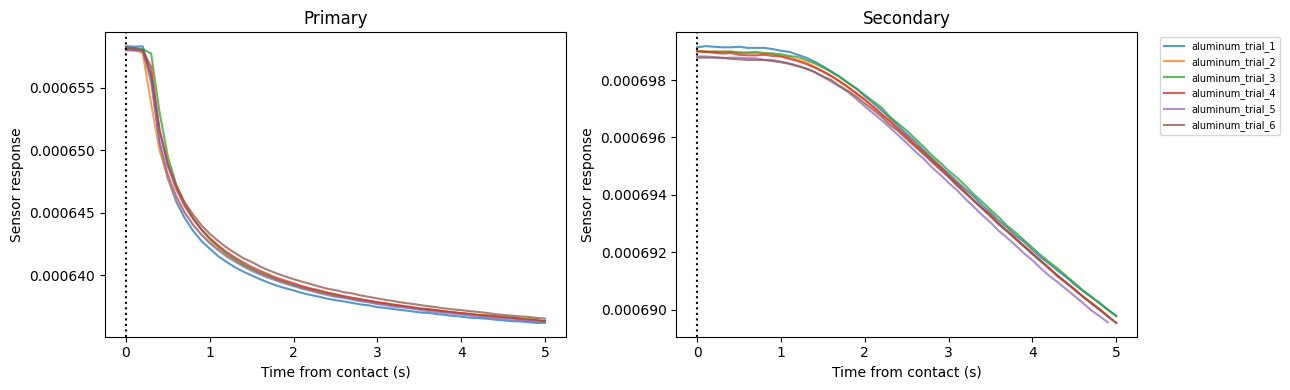

In [42]:
def plot_aligned_trials(material=None, maximum_trials=6):
    selected = list(aligned_trials.values())
    if material is not None:
        selected = [x for x in selected if x["Sample"].iloc[0] == material]
    selected = selected[:maximum_trials]

    fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharex=True)
    for trial in selected:
        label = trial["trial_id"].iloc[0]
        axes[0].plot(trial["time_from_contact"], trial["Primary"], alpha=0.75, label=label)
        axes[1].plot(trial["time_from_contact"], trial["Secondary"], alpha=0.75, label=label)
    for ax, title in zip(axes, ["Primary", "Secondary"]):
        ax.axvline(0, color="black", linestyle=":")
        ax.set(xlabel="Time from contact (s)", ylabel="Sensor response", title=title)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

plot_aligned_trials(material=ALIGNMENT["Sample"].iloc[0])

# 4. Interpretable thermal-response features

Because the analysis interval is only 0–1 s, every feature summarizes the complete
transient. The interval is not subdivided into early, middle, and late windows.


In [43]:
def _smooth(values, window=11, polyorder=2):
    values = np.asarray(values, float)
    selected = min(window, len(values))
    if selected % 2 == 0:
        selected -= 1
    minimum = polyorder + 2
    if minimum % 2 == 0:
        minimum += 1
    return (
        savgol_filter(values, selected, polyorder, mode="interp")
        if selected >= minimum else values.copy()
    )


def _response_slope(time, values):
    valid = np.isfinite(time) & np.isfinite(values)
    if valid.sum() < 3:
        return np.nan
    return float(np.polyfit(time[valid], values[valid], 1)[0])


def extract_thermal_features(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    result = {}

    for name, signal in {
        "primary": primary,
        "secondary": secondary,
        "difference": difference,
    }.items():
        change = signal - signal[0]
        rate = np.gradient(signal, time)
        result[f"{name}_final_change"] = float(change[-1])
        result[f"{name}_max_abs_change"] = float(np.max(np.abs(change)))
        result[f"{name}_response_auc"] = float(np.trapezoid(np.abs(change), time))
        result[f"{name}_response_slope"] = _response_slope(time, signal)
        result[f"{name}_max_abs_rate"] = float(np.max(np.abs(rate)))
        result[f"{name}_rate_auc"] = float(np.trapezoid(np.abs(rate), time))

    # Dimensionless/cross-sensor summaries.
    primary_auc = result["primary_response_auc"]
    result["secondary_primary_auc_ratio"] = (
        result["secondary_response_auc"] / primary_auc
        if not np.isclose(primary_auc, 0) else np.nan
    )
    result["initial_sensor_difference"] = float(difference[0])
    result["final_sensor_difference"] = float(difference[-1])
    return result


thermal_rows = []
for trial_id, trial in aligned_trials.items():
    features = extract_thermal_features(trial)
    features.update({
        "trial_id": trial_id,
        "Sample": trial["Sample"].iloc[0],
        "Trial": int(trial["Trial"].iloc[0]),
        "k": float(trial["k"].iloc[0]),
        "eff": float(trial["eff"].iloc[0]),
    })
    thermal_rows.append(features)

THERMAL_FEATURES = pd.DataFrame(thermal_rows)
print(f"Thermal features: {len(THERMAL_FEATURES.columns) - 5}")
display(THERMAL_FEATURES.head())


Thermal features: 21


,primary_final_change,primary_max_abs_change,primary_response_auc,primary_response_slope,primary_max_abs_rate,primary_rate_auc,secondary_final_change,secondary_max_abs_change,secondary_response_auc,secondary_response_slope,...,difference_max_abs_rate,difference_rate_auc,secondary_primary_auc_ratio,initial_sensor_difference,final_sensor_difference,trial_id,Sample,Trial,k,eff
0,-0.000025,0.000025,0.000102,-0.000003,0.000026,0.000025,-0.000009,0.000009,0.000018,-0.000002,...,0.000026,0.000025,0.173943,-0.000038,-0.000054,aluminum_trial_1,aluminum,1,237.0,23958.094665
1,-0.000024,0.000024,0.000096,-0.000003,0.000027,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000027,0.000024,0.176338,-0.000039,-0.000053,aluminum_trial_2,aluminum,2,237.0,23958.094665
2,-0.000024,0.000024,0.000098,-0.000003,0.000024,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000024,0.000024,0.174287,-0.000039,-0.000053,aluminum_trial_3,aluminum,3,237.0,23958.094665
3,-0.000024,0.000024,0.000097,-0.000003,0.000022,0.000024,-0.000009,0.000009,0.000018,-0.000002,...,0.000022,0.000024,0.183508,-0.000039,-0.000053,aluminum_trial_4,aluminum,4,237.0,23958.094665
4,-0.000024,0.000024,0.000096,-0.000003,0.000024,0.000024,-0.000009,0.000009,0.000017,-0.000002,...,0.000024,0.000024,0.176910,-0.000039,-0.000053,aluminum_trial_5,aluminum,5,237.0,23958.094665


# 5. Manual ESN reservoir and raw trajectory features

Each trial produces a time-by-reservoir-unit state matrix. Every unit is interpolated
onto the same number of post-washout positions and the matrix is flattened into one
trial-level predictor row. Timestamps are never treated as independent observations.

Input scaling is fitted inside each outer training fold. XGBoost receives the raw
flattened ESN features directly; no PCA or predictor standardization is used.


In [44]:
class ManualReservoir:
    def __init__(
        self,
        res_size=30,
        leak_rate=0.9,
        input_magnitude=1.5,
        spectral_radius=1.3,
        washout=0,
        random_state=42,
    ):
        self.res_size = int(res_size)
        self.leak_rate = float(leak_rate)
        self.input_magnitude = float(input_magnitude)
        self.spectral_radius = float(spectral_radius)
        self.washout = int(washout)
        rng = np.random.default_rng(random_state)
        self.Win = (rng.random((self.res_size, 1 + 5)) - 0.5) * self.input_magnitude
        W = rng.random((self.res_size, self.res_size)) - 0.5
        radius = np.max(np.abs(linalg.eigvals(W)))
        if not np.isfinite(radius) or np.isclose(radius, 0):
            raise ValueError("Invalid reservoir spectral radius.")
        self.W = (W / radius.real) * self.spectral_radius

    def run(self, sequence):
        sequence = np.asarray(sequence, float)
        if sequence.ndim != 2 or sequence.shape[1] != 5:
            raise ValueError("Expected sequence with five input channels.")
        if len(sequence) <= self.washout:
            raise ValueError(
                f"Sequence has {len(sequence)} samples, but washout={self.washout}. "
                "Washout must be smaller than the sequence length."
            )
        x = np.zeros((self.res_size, 1))
        states = []
        for row in sequence:
            u = row.reshape(-1, 1)
            x = (
                (1 - self.leak_rate) * x
                + self.leak_rate * np.tanh(
                    self.Win @ np.vstack((1.0, u)) + self.W @ x
                )
            )
            states.append(x[:, 0].copy())
        return np.asarray(states)[self.washout:]


def raw_esn_input(trial):
    time = trial["time_from_contact"].to_numpy(float)
    primary = _smooth(trial["Primary"].to_numpy(float))
    secondary = _smooth(trial["Secondary"].to_numpy(float))
    difference = primary - secondary
    primary_rate = np.gradient(primary, time)
    secondary_rate = np.gradient(secondary, time)
    return np.column_stack([
        primary, secondary, difference, primary_rate, secondary_rate
    ])


def flatten_reservoir_states(time, states, n_time_points=RAW_STATE_TIME_POINTS):
    """Resample a reservoir trajectory and flatten it into one trial-level row."""
    time = np.asarray(time, float)
    states = np.asarray(states, float)
    if states.ndim != 2 or len(time) != len(states):
        raise ValueError("Time and reservoir states must have matching rows.")
    if len(time) < 2 or np.any(np.diff(time) <= 0):
        raise ValueError("Reservoir-state time must be strictly increasing.")

    # Washout removes the earliest states, so resample only within the
    # trajectory that actually remains. This prevents an all-NaN t000 block.
    common_time = np.linspace(time[0], time[-1], int(n_time_points))
    result = {}
    for unit in range(states.shape[1]):
        # Every interpolation point lies inside the retained trajectory.
        trajectory = np.interp(
            common_time, time, states[:, unit], left=np.nan, right=np.nan
        )
        for time_index, value in enumerate(trajectory):
            result[f"esn_t{time_index:03d}_u{unit:03d}"] = float(value)
    return result


# 6. Visualize ESN state evolution

This section shows how the reservoir responds through the 0–1 second post-contact
window. The visualization uses the same reservoir hyperparameters as regression.

The scaler below is fitted across all trials **only for descriptive visualization**.
It is not reused by cross-validation; evaluation continues to fit scaling exclusively
inside each outer training fold.


In [45]:
def compute_visualization_states(trial_id):
    if trial_id not in aligned_trials:
        raise KeyError(trial_id)

    # Descriptive scaler only—never passed into the evaluation engine.
    visualization_scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(trial) for trial in aligned_trials.values()
    ]))
    reservoir = ManualReservoir(
        res_size=ESN_RES_SIZE,
        leak_rate=ESN_LEAK_RATE,
        input_magnitude=ESN_INPUT_MAGNITUDE,
        spectral_radius=ESN_SPECTRAL_RADIUS,
        washout=ESN_WASHOUT,
        random_state=RANDOM_STATE,
    )
    trial = aligned_trials[trial_id]
    scaled_sequence = visualization_scaler.transform(raw_esn_input(trial))
    states = reservoir.run(scaled_sequence)
    time = trial["time_from_contact"].to_numpy(float)[ESN_WASHOUT:]
    return trial, time, scaled_sequence[ESN_WASHOUT:], states


SELECTED_TRIAL_ID = ALIGNMENT["trial_id"].iloc[0]
selected_trial, state_time, selected_inputs, selected_states = (
    compute_visualization_states(SELECTED_TRIAL_ID)
)

print("Selected trial:", SELECTED_TRIAL_ID)
print("Reservoir-state matrix:", selected_states.shape)


Selected trial: aluminum_trial_1
Reservoir-state matrix: (50, 73)


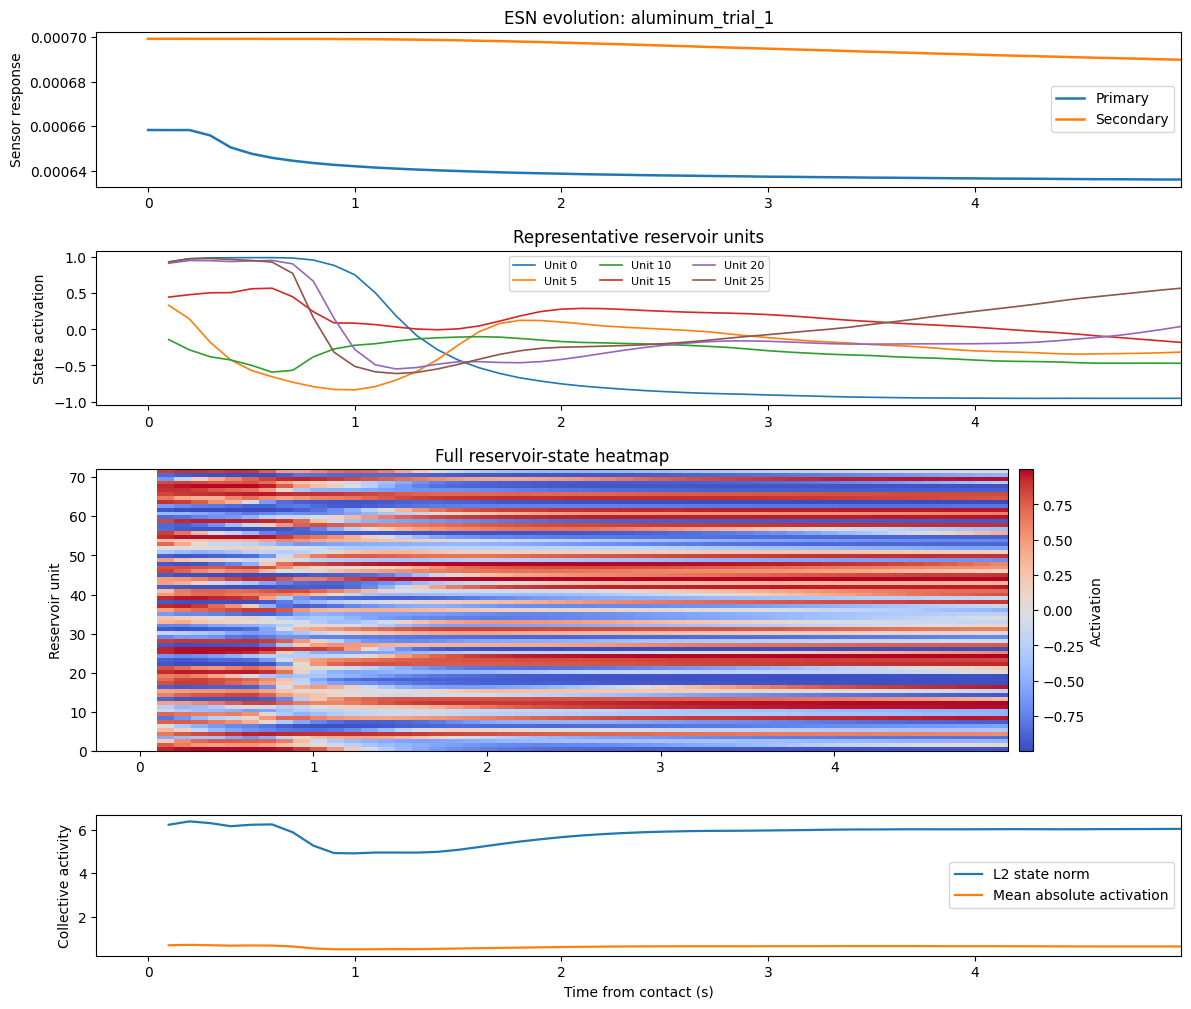

In [46]:
def plot_esn_dynamics(trial_id=SELECTED_TRIAL_ID, units_to_plot=(0, 5, 10, 15, 20, 25)):
    trial, time, scaled_inputs, states = compute_visualization_states(trial_id)

    fig = plt.figure(figsize=(14, 12))
    grid = fig.add_gridspec(4, 1, height_ratios=[1.1, 1.1, 2.0, 1.0], hspace=0.35)

    # Raw sensor response
    ax_inputs = fig.add_subplot(grid[0])
    ax_inputs.plot(
        trial["time_from_contact"], trial["Primary"],
        label="Primary", linewidth=1.8,
    )
    ax_inputs.plot(
        trial["time_from_contact"], trial["Secondary"],
        label="Secondary", linewidth=1.8,
    )
    ax_inputs.set(ylabel="Sensor response", title=f"ESN evolution: {trial_id}")
    ax_inputs.legend(loc="best")

    # Representative reservoir units
    ax_units = fig.add_subplot(grid[1], sharex=ax_inputs)
    valid_units = [unit for unit in units_to_plot if unit < states.shape[1]]
    for unit in valid_units:
        ax_units.plot(time, states[:, unit], label=f"Unit {unit}", linewidth=1.2)
    ax_units.set(ylabel="State activation", title="Representative reservoir units")
    ax_units.legend(ncol=3, fontsize=8)

    # Full state heatmap
    ax_heatmap = fig.add_subplot(grid[2], sharex=ax_inputs)
    limit = np.max(np.abs(states))
    image = ax_heatmap.imshow(
        states.T,
        aspect="auto",
        origin="lower",
        extent=[time.min(), time.max(), 0, states.shape[1] - 1],
        cmap="coolwarm",
        vmin=-limit,
        vmax=limit,
        interpolation="nearest",
    )
    ax_heatmap.set(ylabel="Reservoir unit", title="Full reservoir-state heatmap")
    fig.colorbar(image, ax=ax_heatmap, label="Activation", pad=0.01)

    # Collective reservoir activity
    ax_norm = fig.add_subplot(grid[3], sharex=ax_inputs)
    state_norm = np.linalg.norm(states, axis=1)
    mean_abs_state = np.mean(np.abs(states), axis=1)
    ax_norm.plot(time, state_norm, label="L2 state norm", linewidth=1.6)
    ax_norm.plot(time, mean_abs_state, label="Mean absolute activation", linewidth=1.6)
    ax_norm.set(xlabel="Time from contact (s)", ylabel="Collective activity")
    ax_norm.legend(loc="best")

    plt.show()


plot_esn_dynamics()


## How to interpret the dynamics

- Each heatmap row is one reservoir unit and each column is a post-contact timestep.
- Alternating red and blue patterns show nonlinear units responding with different signs.
- Persistent bands indicate memory of earlier sensor behavior.
- Rapid changes shortly after contact show the reservoir encoding the transient response.
- The state norm summarizes the strength of collective reservoir activation.
- These states are not predictions by themselves; their trajectory summaries become the ESN regression features.


# 7. Leakage-safe XGBoost regression and metrics


In [47]:
def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float)
    y_pred = np.asarray(y_pred, float)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    target_range = np.ptp(y_true)
    return {
        "n": len(y_true),
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": rmse,
        "nrmse_range": rmse / target_range if target_range > 0 else np.nan,
        "r2": r2_score(y_true, y_pred) if len(y_true) > 1 and target_range > 0 else np.nan,
        "median_ape_pct": np.median(np.abs((y_true - y_pred) / y_true)) * 100,
    }


def make_regressor(xgb_params=None, random_state=RANDOM_STATE):
    params = {**XGB_PARAMS, **(xgb_params or {})}
    xgb = XGBRegressor(
        objective="reg:squarederror",
        random_state=int(random_state),
        n_jobs=-1,
        tree_method="hist",
        verbosity=0,
        **params,
    )
    base = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("xgb", xgb),
    ])
    return TransformedTargetRegressor(
        regressor=base,
        func=np.log1p,
        inverse_func=np.expm1,
        check_inverse=False,
    )


# 8. XGBoost evaluation engine


In [48]:
def outer_splits(table, protocol):
    if protocol == "held_out_repetition":
        splitter = GroupKFold(n_splits=table["Trial"].nunique())
        return splitter.split(table, groups=table["Trial"])
    if protocol == "held_out_material":
        splitter = LeaveOneGroupOut()
        return splitter.split(table, groups=table["Sample"])
    raise ValueError("Unknown protocol.")


def build_esn_feature_table(train_ids, all_ids, esn_params=None, random_state=RANDOM_STATE):
    params = {
        "res_size": ESN_RES_SIZE,
        "leak_rate": ESN_LEAK_RATE,
        "input_magnitude": ESN_INPUT_MAGNITUDE,
        "spectral_radius": ESN_SPECTRAL_RADIUS,
        "washout": ESN_WASHOUT,
    }
    params.update(esn_params or {})
    scaler = StandardScaler().fit(np.vstack([
        raw_esn_input(aligned_trials[trial_id]) for trial_id in train_ids
    ]))
    reservoir = ManualReservoir(**params, random_state=random_state)
    rows = []
    for trial_id in all_ids:
        trial = aligned_trials[trial_id]
        sequence = scaler.transform(raw_esn_input(trial))
        states = reservoir.run(sequence)
        state_time = trial["time_from_contact"].to_numpy(float)[params["washout"]:]
        features = flatten_reservoir_states(state_time, states)
        features.update({
            "trial_id": trial_id,
            "Sample": trial["Sample"].iloc[0],
            "Trial": int(trial["Trial"].iloc[0]),
            "k": float(trial["k"].iloc[0]),
            "eff": float(trial["eff"].iloc[0]),
        })
        rows.append(features)
    return pd.DataFrame(rows)


def evaluate_feature_family(feature_family, target, protocol):
    metadata = THERMAL_FEATURES[["trial_id", "Sample", "Trial", "k", "eff"]].copy()
    fold_rows, prediction_rows = [], []

    for fold, (train_idx, test_idx) in enumerate(outer_splits(metadata, protocol), start=1):
        train_meta = metadata.iloc[train_idx]
        test_meta = metadata.iloc[test_idx]
        train_ids = train_meta["trial_id"].tolist()
        test_ids = test_meta["trial_id"].tolist()

        if set(train_ids) & set(test_ids):
            raise RuntimeError("Trial leakage detected.")
        if protocol == "held_out_material" and set(train_meta["Sample"]) & set(test_meta["Sample"]):
            raise RuntimeError("Material leakage detected.")

        if feature_family == "thermal":
            fold_features = THERMAL_FEATURES
        elif feature_family == "esn":
            fold_features = build_esn_feature_table(train_ids, train_ids + test_ids)
        else:
            raise ValueError("feature_family must be thermal or esn")

        indexed = fold_features.set_index("trial_id")
        excluded = {"Sample", "Trial", "k", "eff"}
        feature_cols = [
            c for c in fold_features.select_dtypes(include=np.number).columns
            if c not in excluded
        ]
        X_train = indexed.loc[train_ids, feature_cols].reset_index(drop=True)
        X_test = indexed.loc[test_ids, feature_cols].reset_index(drop=True)
        y_train = indexed.loc[train_ids, target].reset_index(drop=True)
        y_test = indexed.loc[test_ids, target].reset_index(drop=True)

        model = make_regressor()
        model.fit(X_train, y_train)
        pred = np.clip(model.predict(X_test), y_train.min(), y_train.max())

        fold_rows.append({
            "fold": fold,
            "feature_family": feature_family,
            "target": target,
            "protocol": protocol,
            "test_materials": ", ".join(sorted(set(test_meta["Sample"]))),
            **regression_metrics(y_test, pred),
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": test_ids,
            "Sample": test_meta["Sample"].to_numpy(),
            "Trial": test_meta["Trial"].to_numpy(),
            "fold": fold,
            "y_true": y_test,
            "y_pred": pred,
        }))

    fold_metrics = pd.DataFrame(fold_rows)
    predictions = pd.concat(prediction_rows, ignore_index=True)
    overall = pd.DataFrame([{
        "feature_family": feature_family,
        "target": target,
        "protocol": protocol,
        **regression_metrics(predictions["y_true"], predictions["y_pred"]),
    }])
    return fold_metrics, overall, predictions


# 9. Fixed Temperature: held-out repetitions

This protocol tests a new experimental repetition while other trials of the same
materials remain in training. It is the appropriate primary measure of repeatability.


In [49]:
repetition_results = []
repetition_predictions = {}

for family in ("thermal", "esn"):
    for target in ("k", "eff"):
        folds, overall, predictions = evaluate_feature_family(
            family, target, "held_out_repetition"
        )
        repetition_results.append(overall)
        repetition_predictions[(family, target)] = predictions

REPETITION_RESULTS = pd.concat(repetition_results, ignore_index=True)
display(REPETITION_RESULTS)

,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,k,held_out_repetition,84,44.309567,89.010059,0.221989,0.380700,29.265791
1,thermal,eff,held_out_repetition,84,2767.304016,5420.210246,0.145869,0.766138,12.813648
2,esn,k,held_out_repetition,84,35.848184,74.616221,0.186091,0.564799,23.101647
3,esn,eff,held_out_repetition,84,2165.474194,4596.465351,0.123700,0.831819,8.575041


# 10. Fixed Temperature: held-out materials

This protocol excludes every trial of one material. It estimates whether the model can
predict properties for a material absent from training. This is the more difficult and
more important test for unseen-material claims.


In [50]:
material_results = []
material_predictions = {}

for family in ("thermal", "esn"):
    for target in ("k", "eff"):
        folds, overall, predictions = evaluate_feature_family(
            family, target, "held_out_material"
        )
        material_results.append(overall)
        material_predictions[(family, target)] = predictions

MATERIAL_RESULTS = pd.concat(material_results, ignore_index=True)
display(MATERIAL_RESULTS)


,feature_family,target,protocol,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,thermal,k,held_out_material,84,56.913367,107.556547,0.268244,0.095733,67.323805
1,thermal,eff,held_out_material,84,3863.948608,6676.813960,0.179687,0.645132,40.325854
2,esn,k,held_out_material,84,52.629414,101.978039,0.254331,0.187102,63.543470
3,esn,eff,held_out_material,84,3514.432298,6619.509173,0.178144,0.651197,35.584939


# 11. Compare actual and predicted values


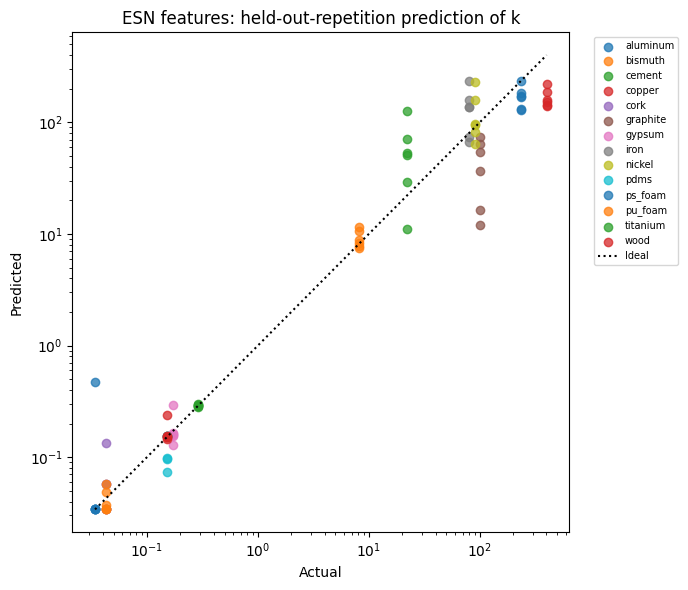

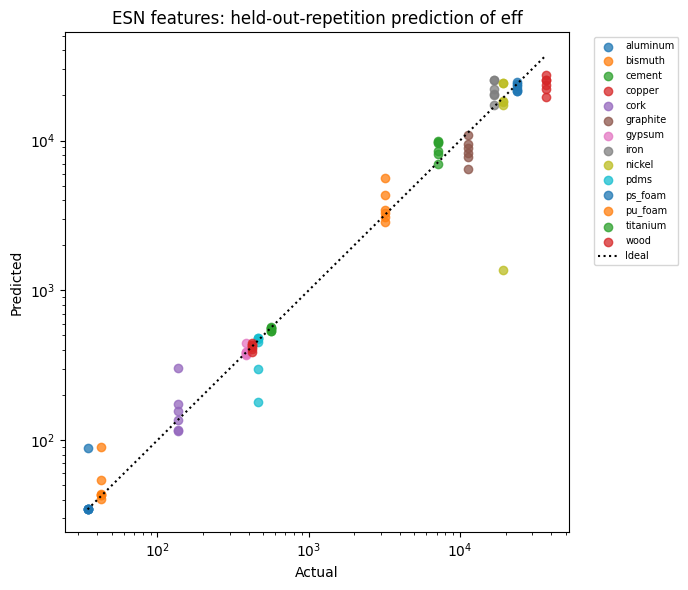

In [51]:
def plot_actual_predicted(predictions, title):
    positive = (predictions["y_true"] > 0) & (predictions["y_pred"] > 0)
    shown = predictions[positive]
    fig, ax = plt.subplots(figsize=(7, 6))
    for material, part in shown.groupby("Sample"):
        ax.scatter(part["y_true"], part["y_pred"], label=material, alpha=0.75)
    low = min(shown["y_true"].min(), shown["y_pred"].min())
    high = max(shown["y_true"].max(), shown["y_pred"].max())
    ax.plot([low, high], [low, high], color="black", linestyle=":", label="Ideal")
    ax.set(xscale="log", yscale="log", xlabel="Actual", ylabel="Predicted", title=title)
    ax.legend(fontsize=7, bbox_to_anchor=(1.04, 1), loc="upper left")
    fig.tight_layout()
    plt.show()

plot_actual_predicted(
    repetition_predictions[("esn", "k")],
    "ESN features: held-out-repetition prediction of k",
)
plot_actual_predicted(
    repetition_predictions[("esn", "eff")],
    "ESN features: held-out-repetition prediction of eff",
)


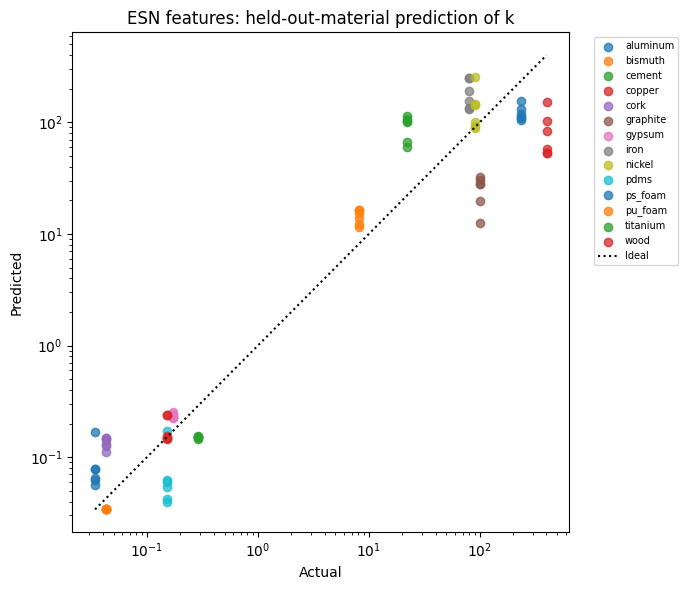

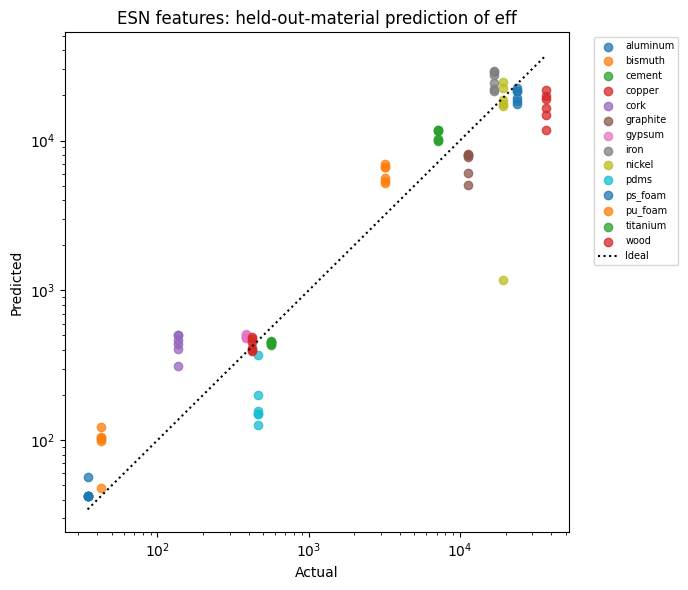

In [52]:
plot_actual_predicted(
    material_predictions[("esn", "k")],
    "ESN features: held-out-material prediction of k",
)
plot_actual_predicted(
    material_predictions[("esn", "eff")],
    "ESN features: held-out-material prediction of eff",
)


# 12. Nested Bayesian optimization of ESN hyperparameters

The objective is generalization to unseen materials. Within every outer LOMO training
set, a Gaussian-process surrogate models the inner-validation loss:

\[
J = \operatorname{mean}(\mathrm{NRMSE}_{inner\ folds})
    + \lambda\,\operatorname{SD}(\mathrm{NRMSE}_{inner\ folds}).
\]

After several random initialization trials, expected improvement chooses promising
ESN configurations. The outer held-out material is never used by the optimizer.
XGBoost settings remain fixed so the search isolates the effects of ESN dynamics.

The reported nested OOF score is an unbiased estimate for the complete selection
procedure. A final Bayesian search on all materials produces deployment parameters;
that final recommendation is not another independent performance estimate.


In [53]:
BAYES_SPACE = {
    "res_size": ("integer", 10, 80),
    "leak_rate": ("float", 0.05, 0.95),
    "input_magnitude": ("float", 0.25, 2.00),
    "spectral_radius": ("float", 0.30, 1.50),
    "washout": ("integer", 0, 5),
}
BAYES_KEYS = tuple(BAYES_SPACE)


def _decode_bayes_point(point):
    """Map a unit-hypercube point to valid ESN parameters."""
    params = {}
    for key, coordinate in zip(BAYES_KEYS, np.clip(point, 0.0, 1.0)):
        kind, low, high = BAYES_SPACE[key]
        value = low + float(coordinate) * (high - low)
        params[key] = int(round(value)) if kind == "integer" else float(value)
    return params


def _predict_esn_fold(train_meta, valid_meta, target, params, random_states):
    train_ids = train_meta["trial_id"].tolist()
    valid_ids = valid_meta["trial_id"].tolist()
    if set(train_ids) & set(valid_ids):
        raise RuntimeError("Trial leakage detected during Bayesian search.")
    if set(train_meta["Sample"]) & set(valid_meta["Sample"]):
        raise RuntimeError("Material leakage detected during Bayesian search.")

    seed_predictions = []
    for random_state in random_states:
        features = build_esn_feature_table(
            train_ids,
            train_ids + valid_ids,
            esn_params=params,
            random_state=random_state,
        ).set_index("trial_id")
        feature_cols = [c for c in features if c.startswith("esn_")]
        X_train = features.loc[train_ids, feature_cols].reset_index(drop=True)
        X_valid = features.loc[valid_ids, feature_cols].reset_index(drop=True)
        y_train = features.loc[train_ids, target].reset_index(drop=True)

        model = make_regressor(random_state=random_state)
        model.fit(X_train, y_train)
        seed_predictions.append(np.clip(
            model.predict(X_valid), y_train.min(), y_train.max()
        ))

    return valid_meta[target].to_numpy(float), np.mean(seed_predictions, axis=0)


def _inner_objective(metadata, target, params, n_splits, random_states, stability_weight):
    splitter = GroupKFold(n_splits=n_splits)
    rows = []
    for fold, (train_idx, valid_idx) in enumerate(
        splitter.split(metadata, groups=metadata["Sample"]), start=1
    ):
        y_true, y_pred = _predict_esn_fold(
            metadata.iloc[train_idx], metadata.iloc[valid_idx],
            target, params, random_states,
        )
        rows.append({"fold": fold, **regression_metrics(y_true, y_pred)})

    fold_metrics = pd.DataFrame(rows)
    values = fold_metrics["nrmse_range"].dropna()
    if values.empty:
        return np.inf, fold_metrics
    mean_nrmse = float(values.mean())
    sd_nrmse = float(values.std(ddof=0))
    return mean_nrmse + stability_weight * sd_nrmse, fold_metrics


def bayesian_optimize_esn(
    metadata,
    target="eff",
    n_trials=BAYES_N_TRIALS,
    n_initial=BAYES_N_INITIAL,
    inner_splits=4,
    random_states=(42, 43, 44),
    stability_weight=BAYES_STABILITY_WEIGHT,
    acquisition_candidates=BAYES_ACQUISITION_CANDIDATES,
    optimizer_seed=2026,
):
    """Minimize grouped-CV loss using GP expected improvement."""
    if n_trials < 2 or not 1 <= n_initial <= n_trials:
        raise ValueError("Require n_trials >= 2 and 1 <= n_initial <= n_trials.")
    if inner_splits < 2 or inner_splits > metadata["Sample"].nunique():
        raise ValueError("Invalid number of inner material folds.")
    if not random_states:
        raise ValueError("At least one reservoir seed is required.")

    rng = np.random.default_rng(optimizer_seed)
    points, losses, rows = [], [], []

    for trial_number in range(1, n_trials + 1):
        if trial_number <= n_initial:
            point = rng.random(len(BAYES_KEYS))
            acquisition = "random_initialization"
        else:
            X_observed = np.asarray(points)
            y_observed = np.asarray(losses)
            kernel = (
                ConstantKernel(1.0, (1e-2, 1e2))
                * Matern(length_scale=np.ones(len(BAYES_KEYS)), nu=2.5)
                + WhiteKernel(noise_level=1e-5, noise_level_bounds=(1e-8, 1e-1))
            )
            gp = GaussianProcessRegressor(
                kernel=kernel,
                normalize_y=True,
                random_state=optimizer_seed + trial_number,
                n_restarts_optimizer=2,
            )
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                gp.fit(X_observed, y_observed)
            candidates = rng.random((acquisition_candidates, len(BAYES_KEYS)))
            mean, std = gp.predict(candidates, return_std=True)
            improvement = np.min(y_observed) - mean - 0.01
            z = np.divide(improvement, std, out=np.zeros_like(std), where=std > 0)
            expected_improvement = improvement * norm.cdf(z) + std * norm.pdf(z)
            point = candidates[int(np.argmax(expected_improvement))]
            acquisition = "expected_improvement"

        params = _decode_bayes_point(point)
        loss, fold_metrics = _inner_objective(
            metadata, target, params, inner_splits,
            tuple(random_states), stability_weight,
        )
        points.append(point)
        losses.append(loss)
        rows.append({
            "trial": trial_number,
            "acquisition": acquisition,
            **params,
            "mean_inner_nrmse": float(fold_metrics["nrmse_range"].mean()),
            "sd_inner_nrmse": float(fold_metrics["nrmse_range"].std(ddof=0)),
            "mean_inner_r2": float(fold_metrics["r2"].mean()),
            "performance_index": loss,
        })
        print(f"  Bayesian trial {trial_number:02d}/{n_trials}: J={loss:.4f}")

    history = pd.DataFrame(rows).sort_values("performance_index").reset_index(drop=True)
    best_params = {key: history.loc[0, key] for key in BAYES_KEYS}
    best_params["res_size"] = int(best_params["res_size"])
    best_params["washout"] = int(best_params["washout"])
    return history, best_params


def nested_lomo_bayesian_esn_search(
    target="eff",
    n_trials=BAYES_N_TRIALS,
    n_initial=BAYES_N_INITIAL,
    inner_splits=4,
    random_states=(42, 43, 44),
    stability_weight=BAYES_STABILITY_WEIGHT,
):
    metadata = THERMAL_FEATURES[
        ["trial_id", "Sample", "Trial", "k", "eff"]
    ].reset_index(drop=True)
    outer_splitter = LeaveOneGroupOut()
    search_rows, outer_rows, prediction_rows = [], [], []

    splits = list(outer_splitter.split(metadata, groups=metadata["Sample"]))
    for outer_fold, (train_idx, test_idx) in enumerate(splits, start=1):
        outer_train = metadata.iloc[train_idx].reset_index(drop=True)
        outer_test = metadata.iloc[test_idx].reset_index(drop=True)
        held_out = outer_test["Sample"].iloc[0]
        print(f"Outer fold {outer_fold}/{len(splits)}: held out {held_out}")

        history, best_params = bayesian_optimize_esn(
            outer_train,
            target=target,
            n_trials=n_trials,
            n_initial=n_initial,
            inner_splits=inner_splits,
            random_states=random_states,
            stability_weight=stability_weight,
            optimizer_seed=2026 + outer_fold,
        )
        history.insert(0, "outer_fold", outer_fold)
        history.insert(1, "held_out_material", held_out)
        search_rows.append(history)

        y_true, y_pred = _predict_esn_fold(
            outer_train, outer_test, target, best_params, tuple(random_states)
        )
        outer_rows.append({
            "outer_fold": outer_fold,
            "held_out_material": held_out,
            **best_params,
            **regression_metrics(y_true, y_pred),
        })
        prediction_rows.append(pd.DataFrame({
            "trial_id": outer_test["trial_id"].to_numpy(),
            "Sample": outer_test["Sample"].to_numpy(),
            "Trial": outer_test["Trial"].to_numpy(),
            "outer_fold": outer_fold,
            "y_true": y_true,
            "y_pred": y_pred,
        }))

    searches = pd.concat(search_rows, ignore_index=True)
    outer_results = pd.DataFrame(outer_rows)
    predictions = pd.concat(prediction_rows, ignore_index=True)
    nested_metrics = pd.DataFrame([{
        "target": target,
        "protocol": "nested_lomo_bayesian_xgboost",
        "n_bayesian_trials": n_trials,
        "random_states": tuple(random_states),
        **regression_metrics(predictions["y_true"], predictions["y_pred"]),
    }])

    print("Final Bayesian search on all materials for deployment parameters")
    final_history, recommended = bayesian_optimize_esn(
        metadata,
        target=target,
        n_trials=n_trials,
        n_initial=n_initial,
        inner_splits=inner_splits,
        random_states=random_states,
        stability_weight=stability_weight,
        optimizer_seed=4042,
    )
    return searches, outer_results, predictions, nested_metrics, final_history, recommended


In [54]:
BAYES_TARGET = "eff"  # Run separately for "k" if conductivity is also a target.
RANDOM_STATES = (42, 43, 44)

# Runtime is approximately proportional to:
# outer materials × Bayesian trials × inner folds × reservoir seeds.
# For a quick code check only, use BAYES_N_TRIALS=8, BAYES_N_INITIAL=4,
# inner_splits=3, and RANDOM_STATES=(42,).
(
    BAYES_SEARCH_HISTORY,
    BAYES_OUTER_RESULTS,
    BAYES_PREDICTIONS,
    BAYES_NESTED_METRICS,
    BAYES_FINAL_HISTORY,
    RECOMMENDED_ESN_PARAMETERS,
) = nested_lomo_bayesian_esn_search(
    target=BAYES_TARGET,
    n_trials=BAYES_N_TRIALS,
    n_initial=BAYES_N_INITIAL,
    inner_splits=4,
    random_states=RANDOM_STATES,
    stability_weight=BAYES_STABILITY_WEIGHT,
)

print("Unbiased nested-LOMO performance:")
display(BAYES_NESTED_METRICS)
print("Per-material outer-fold results:")
display(BAYES_OUTER_RESULTS)
print("Recommended ESN parameters for a future fitted model:")
display(pd.Series(RECOMMENDED_ESN_PARAMETERS))
print("Best trials from the final Bayesian search:")
display(BAYES_FINAL_HISTORY.head(10))


Outer fold 1/14: held out aluminum
  Bayesian trial 01/24: J=0.4806
  Bayesian trial 02/24: J=0.3459
  Bayesian trial 03/24: J=0.4540
  Bayesian trial 04/24: J=0.2618
  Bayesian trial 05/24: J=0.3981
  Bayesian trial 06/24: J=0.7802
  Bayesian trial 07/24: J=0.2070
  Bayesian trial 08/24: J=0.3604
  Bayesian trial 09/24: J=0.4718
  Bayesian trial 10/24: J=0.3364
  Bayesian trial 11/24: J=0.5175
  Bayesian trial 12/24: J=0.3792
  Bayesian trial 13/24: J=0.3281
  Bayesian trial 14/24: J=0.2352
  Bayesian trial 15/24: J=0.2140
  Bayesian trial 16/24: J=0.4641
  Bayesian trial 17/24: J=0.3753
  Bayesian trial 18/24: J=0.3116
  Bayesian trial 19/24: J=0.3223
  Bayesian trial 20/24: J=0.4436
  Bayesian trial 21/24: J=0.2236
  Bayesian trial 22/24: J=0.4718
  Bayesian trial 23/24: J=0.5202
  Bayesian trial 24/24: J=0.5220
Outer fold 2/14: held out bismuth
  Bayesian trial 01/24: J=0.2505
  Bayesian trial 02/24: J=0.9813
  Bayesian trial 03/24: J=0.6018
  Bayesian trial 04/24: J=0.9190
  Bayes

,target,protocol,n_bayesian_trials,random_states,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,eff,nested_lomo_bayesian_xgboost,24,"(42, 43, 44)",84,3532.490814,6597.807781,0.17756,0.653481,34.056233


Per-material outer-fold results:


,outer_fold,held_out_material,res_size,leak_rate,input_magnitude,spectral_radius,washout,n,mae,rmse,nrmse_range,r2,median_ape_pct
0,1,aluminum,61,0.215952,1.516512,0.467697,5,6,6109.263665,6359.954595,NaN,NaN,26.154670
1,2,bismuth,25,0.263941,0.693065,0.530665,1,6,2449.550020,2709.831379,NaN,NaN,90.208062
2,3,cement,17,0.848745,1.844341,1.223617,1,6,112.624031,119.271841,NaN,NaN,22.863985
3,4,copper,78,0.948477,1.662354,1.271624,5,6,19876.179594,19957.777297,NaN,NaN,52.909565
4,5,cork,75,0.307824,0.487496,1.132162,2,6,131.493231,139.381573,NaN,NaN,112.289983
5,6,graphite,12,0.886923,1.856324,1.037891,4,6,2648.431201,3095.721586,NaN,NaN,21.676399
6,7,gypsum,19,0.694671,1.334930,0.616807,3,6,49.652643,51.922521,NaN,NaN,10.818329
7,8,iron,13,0.369364,1.109916,1.383098,3,6,8403.394964,9362.281463,NaN,NaN,41.827988
8,9,nickel,72,0.229920,1.024979,0.811189,0,6,5877.175951,7122.711347,NaN,NaN,21.587907
9,10,pdms,40,0.273688,1.604986,1.221988,5,6,268.702367,277.198698,NaN,NaN,52.417746


Recommended ESN parameters for a future fitted model:


res_size           73.000000
leak_rate           0.755731
input_magnitude     0.991535
spectral_radius     1.103213
washout             5.000000
dtype: float64

Best trials from the final Bayesian search:


,trial,acquisition,res_size,leak_rate,input_magnitude,spectral_radius,washout,mean_inner_nrmse,sd_inner_nrmse,mean_inner_r2,performance_index
0,6,random_initialization,73,0.755731,0.991535,1.103213,5,0.165321,0.067364,0.807905,0.182162
1,14,expected_improvement,73,0.680263,1.325105,0.892286,4,0.168308,0.088189,0.780324,0.190355
2,20,expected_improvement,59,0.167613,0.698298,0.671343,1,0.184028,0.073799,0.763037,0.202477
3,13,expected_improvement,59,0.736131,1.711086,0.369451,4,0.204982,0.068701,0.716830,0.222157
4,24,expected_improvement,26,0.724049,0.876176,0.654453,4,0.230525,0.052167,0.666854,0.243566
5,10,expected_improvement,79,0.755681,1.194661,0.482921,4,0.244715,0.054069,0.624834,0.258233
6,5,random_initialization,57,0.736468,0.755966,0.804106,3,0.255743,0.094302,0.560914,0.279319
7,15,expected_improvement,35,0.865115,1.246470,1.321151,1,0.281449,0.081997,0.491123,0.301949
8,12,expected_improvement,26,0.640382,0.690554,1.096974,4,0.282924,0.082319,0.485400,0.303504
9,18,expected_improvement,67,0.495689,0.662439,1.221742,4,0.286979,0.077993,0.475275,0.306477


## Reading the Bayesian-search result

- `BAYES_NESTED_METRICS` is the leakage-safe performance estimate. Every prediction
  is for a material excluded from fitting and Bayesian hyperparameter selection.
- `BAYES_OUTER_RESULTS` shows performance and selected ESN settings by material.
- `BAYES_SEARCH_HISTORY` records the evaluated Bayesian trials inside every outer fold.
- `BAYES_FINAL_HISTORY` is the final search over all available materials.
- `RECOMMENDED_ESN_PARAMETERS` is for fitting a future model. Its inner-CV score is
  not an additional independent test score.

Bayesian optimization is efficient, but it does not prove a global mathematical
optimum. Report the search space, number of trials, acquisition function, seeds, and
nested-CV design alongside the selected configuration.


# 13. Interpretation rules

- High held-out-repetition performance shows repeatability for represented materials.
- Only held-out-material performance supports a claim about unseen materials.
- `k` and `eff` are targets and are never included as predictors.
- Raw ESN trajectories are resampled and flattened per trial; XGBoost receives them directly.
- XGBoost models nonlinearities and feature interactions but can overfit this small dataset.
- Bayesian optimization occurs only inside each outer training set for the nested estimate.
- Multiple reservoir seeds reduce sensitivity to one random reservoir realization.
- Bayesian optimization finds the best observed configuration, not a guaranteed global optimum.
- Poor held-out-material results remain a generalization finding, not automatically a coding error.
